<a href="https://colab.research.google.com/github/Andres-Gress/Simulacion-I/blob/main/Tercer_Parcial_Simulacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Línea de Espera con dos Servidores en Serie**

Es importante recalcar un poco de notación para la simulación de esta línea de espera:

**Variable del tiempo $t$**

**Variable de estado del sistema (ES)**

$(n_1,n_2):$ Si hay $n_1$ clientes en el servidor 1 (incluyendo los formados y los que están en servicio) y $n_2$ clientes en el servidor 2.

**Variables de Conteo**

$N_A:$ el número de llegadas hasta el instante $t$

$N_D:$ el número de salidas hasta el instante $t$

**Variables de Salida**

$A_1(n):$ la hora de llegada del cliente $n,n\geq 1$

$A_2(n):$ la hora de llegada del cliente $n$ al servidor $2, n\geq 1$

$D(n):$ la hora de salida del cliente $n, n\geq 1$

**Lista de eventos** $t_A, t_1, t_2$ donde $t_A$ es la hora de la siguiente llegada, y $t_i$ es la hora a la que concluye el servicio del cliente actualmente atendido por el servidor $i, i=1,2$.

Si en un momento dado mo se encuentra un cliente con el servidor $i$, entonces $t_i=\infty, i =1,2$. La lista de eventos siempre consta de tres variables $t_A, t_1,t_2$

In [ ]:
import random as r
from collections import deque
import numpy as np

Se importan las librerias necesarias para realizar cada cálculo

In [ ]:
def serie2(lam, mu1, mu2, T_max):

    t = 0
    NA = 0
    ND = 0

    n1 = 0
    n2 = 0

    tA = r.expovariate(lam)
    t1 = float("inf")
    t2 = float("inf")

    A1 = {}
    A2 = {}
    D = {}

    while t < T_max:

        # CASO 1
        if tA <= t1 and tA <= t2:

            t = tA
            if t > T_max:
                break

            NA += 1
            n1 += 1

            T = r.expovariate(lam)
            tA = t + T

            if n1 == 1:
                Y1 = r.expovariate(mu1)
                t1 = t + Y1

            A1[NA] = t

        # CASO 2
        elif t1 < tA and t1 <= t2:

            t = t1
            if t > T_max:
                break

            n1 -= 1
            n2 += 1

            if n1 == 0:
                t1 = float("inf")
            else:
                Y1 = r.expovariate(mu1)
                t1 = t + Y1

            if n2 == 1:
                Y2 = r.expovariate(mu2)
                t2 = t + Y2

            A2[NA - n1] = t

        # CASO 3
        elif t2 < tA and t2 < t1:

            t = t2
            if t > T_max:
                break

            ND += 1
            n2 -= 1

            if n2 == 0:
                t2 = float("inf")
            else:
                Y2 = r.expovariate(mu2)
                t2 = t + Y2

            D[ND] = t

    return NA, ND, t, A1, A2, D

Se define la función la cual retorna $N_A, N_D, t, A_1, A_2, D$ los cuales son datos muy importantes para realizar otro tipo de cálculos, en especial se desea saber las cantidades de tiempo que un cliente pasa en ambos servidores

In [ ]:
NA, ND, t, A1, A2, D = serie2(1, 5, 4, 1000)

t_s1 = []
t_s2 = []
t_total = []

for i in A1:

    if i in A2 and i in D:

        s1 = A2[i] - A1[i]
        s2 = D[i] - A2[i]
        total = D[i] - A1[i]

        t_s1.append(s1)
        t_s2.append(s2)
        t_total.append(total)


print("Tiempo promedio en S1:", sum(t_s1)/len(t_s1) if t_s1 else 0)
print("Tiempo promedio en S2:", sum(t_s2)/len(t_s2) if t_s2 else 0)
print("Tiempo promedio Total:", sum(t_total)/len(t_total) if t_total else 0)

Tiempo promedio en S1: 0.24032193926034282
Tiempo promedio en S2: 0.3285332162534311
Tiempo promedio Total: 0.568855155513774


Aquí en base a los datos obtenidos anteriormente, se obtienen los promedios del tiempo que pasaa un cliente en cada servidor, de igual manera si se desea se pueden obtener otros resultados interesantes.

# **Linea de espera de 2 servidores en Paralelo**

Para poder simular este caso es importante mencionar los siguientes conceptos y notación:

**Variable de tiempo $t$**

**Variable de estado del sistema (ES)**

$(n,i_1,i_2,...,i_n)$ si hay $n$ clientes en el sistema, $i_1$ está con el servidor 1, $i_2$ está con el servidor 2, $i_3$ es el primero de la fila, $i_4$ es el siguiente, y así sucesivamente.

Cabe recalcar que **ES=(0)** cuando el sistema está vacío, y **ES=(1,j,0) o (1,0,j)** cuando el único cliente es j y éste es atendido por el servidor 1 o el 2, respectivamente.

**Variables de Conteo**

$$N_A: \text{ el número de llegadas hasta el instante } t$$

$$C_j: \text{ el número de clientes atendidos por } j, j=1,2 \text{ hasta el instante } t$$

**Variables de Salida**

$$A(n): \text{ la hora de llegada del cleinte } n,n\geq 1$$

$$D(n): \text{la hora de salida del cliente } n, n\geq 1$$

**Lista de eventos $t_A,t_1,t_2$**

Donde $t_A$ es la hora de la siguiente llegada y $t_1$ es la hora en la que concluye el servicio del cliente que en ese momento está siendo atendido por el servidor $i,i=1,2$. Si no hay un cliente actualmente en el servidor $i$, entonces hacemos $t_i=\infty, i=1,2$

In [ ]:
def paralelo2(lam, mu1, mu2, T_max):

    t = 0
    NA = 0
    C1 = 0
    C2 = 0

    ES = [0]

    A = {}
    D = {}
    S = {}

    t_A = r.expovariate(lam)
    t_1 = float("inf")
    t_2 = float("inf")

    while t < T_max:

        # CASO 1
        if t_A <= t_1 and t_A <= t_2:

            t = t_A
            if t > T_max:
                break

            NA += 1
            A[NA] = t

            t_A = t + r.expovariate(lam)

            if ES == [0]:
                ES = [1, NA, 0]
                S[NA] = 1
                t_1 = t + r.expovariate(mu1)

            elif ES[0] == 1 and ES[2] == 0:
                j = ES[1]
                ES = [2, j, NA]
                S[NA] = 2
                t_2 = t + r.expovariate(mu2)

            elif ES[0] == 1 and ES[1] == 0:
                j = ES[2]
                ES = [2, NA, j]
                S[NA] = 1
                t_1 = t + r.expovariate(mu1)

            else:
                ES[0] += 1
                ES.append(NA)

        # CASO 2
        elif t_1 < t_A and t_1 <= t_2:

            t = t_1
            if t > T_max:
                break

            n = ES[0]
            i1 = ES[1]

            C1 += 1
            D[i1] = t

            if n == 1:
                ES = [0]
                t_1 = float("inf")

            elif n == 2:
                ES = [1, 0, ES[2]]
                t_1 = float("inf")

            else:
                ES = [n - 1, ES[3], ES[2]] + ES[4:]
                t_1 = t + r.expovariate(mu1)

        # CASO 3
        else:

            t = t_2
            if t > T_max:
                break

            n = ES[0]
            i2 = ES[2]

            C2 += 1
            D[i2] = t

            if n == 1:
                ES = [0]
                t_2 = float("inf")

            elif n == 2:
                ES = [1, ES[1], 0]
                t_2 = float("inf")

            else:
                ES = [n - 1, ES[1], ES[3]] + ES[4:]
                t_2 = t + r.expovariate(mu2)

    tiempos = []
    for i in A:
        if i in D:
            tiempos.append(D[i] - A[i])

    return {
        "C1": C1,
        "C2": C2,
        "tiempo_promedio_sistema": sum(tiempos)/len(tiempos) if tiempos else 0,
        "clientes_atendidos": len(tiempos)
    }

Se define la fución de acuerdo al pesudocódigo propuesto por Ross, donde se quiere simular una línea de espera en paralelo de 2 servidores, pero se quiere mantener un registro de las cantidades de tiempo que pasa cada cliente dentro del sistema y el número de servicios realizados por cada servidor.

In [ ]:
lam = 2
mu1 = 2
mu2 = 3
T_max = 12

paralelo2(lam, mu1, mu2, T_max)

{'C1': 16,
 'C2': 13,
 'tiempo_promedio_sistema': 0.4693224065823614,
 'clientes_atendidos': 29}

Por ejemplo, para una simulación con $\lambda=2, \mu_1=2, \mu_2=3$ y un tiempo máximo de $12$ (horas por decir una unidad de tiempo). Se retorna el tiempo promedio que estuvo cada cliente en el sistema, ya sea que fuera atendido por un servidor u otro y se da el total de clientes atendidos.

#**VARIABLES ANTITETICAS**

Aplicadas a la estimación de la integral

$$\int_0^1 e^{x^2} dx$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random as r

Partimos importando las librerias necesarias para realizar los cálculos

In [ ]:
def f(x):
   return np.exp(x**2)

Se define la función de la cual se desea estimar su área bajo la curva en un intervalo dado, en este caso $f(x) = e^{x^2}$

In [ ]:
def mc1(f,n):
    s=0
    for i in range(n):
        U = r.random()
        s += f(U)
    return s/n

Función de Monte Carlo Crudo, donde aún no se aplica la reducción de varianza

In [ ]:
l1 = []
for i in range(100):
    M = mc1(f,1000)
    l1.append(M)
print(np.mean(l1))
print(np.var(l1))

1.4614702724909745
0.0002474837499763952


Al llamar $100$ veces a la función de MC se da una aproximación muy buena del valor de la integral, así como su varianza, la cuál parece ser pequeña.

In [ ]:
mu = np.mean(l1)
s = np.std(l1)
IC = [mu-1.96*s,mu + 1.96*s]
IC

[np.float64(1.4306363046323074), np.float64(1.4923042403496416)]

Se da un intervalo de confianza al $95%$ del valor real de la integral, esto utilizando la media y desviación estándar.

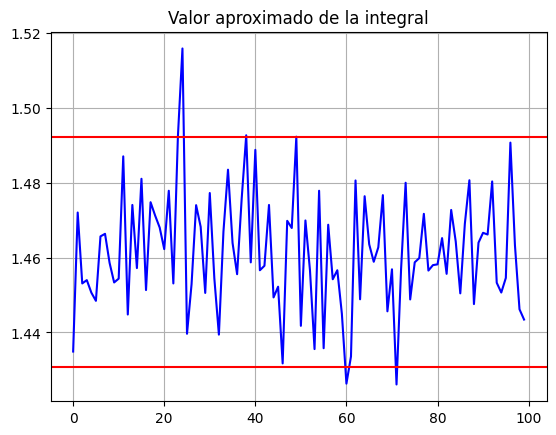

In [ ]:
plt.plot(l1, color = "blue")
plt.axhline(mu-1.96*s, color ="red")
plt.axhline(mu+1.96*s, color = "red")
plt.title("Valor aproximado de la integral")
plt.grid()
plt.show()

Gráfica de la primera aproximación de por donde fluctua el valor real de la integral y las líneas rojas, son los intervalos de confianza, que indican que el valor real se encuentra dentro de ellos (son cotas).

In [ ]:
def mc2(f,n):
    s=0
    for i in range(n):
        U = r.random()
        s += f(1-U)
    return s/n

Analogamente al MC1, se crea MC2 que basicamente es lo mismo, con la única diferencia que al evaluar en $f$, no se evalúa $U$, sino $1-U$ que es un claro ejemplo de variables antitéticas que siguen una distribución $N(0,1)$

In [ ]:
l2 = []
for i in range(100):
    M = mc2(f,1000)
    l2.append(M)
print(np.mean(l2))
print(np.var(l2))

1.4647779497207143
0.0002182064877838003


Se piden los mismos datos: media (valor estimado de la integral) y varianza al llamar a MC2 100 veces

In [ ]:
def mc(f,n):
    s=0
    for i in range(n):
        U = r.random()
        s += (f(U)+f(1-U))/2
    return s/n

Ahora se crea la función donde se realizará la reducción de varianza dado que $U$ y $1-U$ son antitéticas, en las que básicamente se obtiene el promedio de usar las VA.

In [ ]:
l = []
for i in range(100):
    M = mc(f,1000)
    l.append(M)
print(np.mean(l))
print(np.var(l))

1.4620548994795715
3.318366986145276e-05


Se pide lo mismo y se aprecia que la varianza disminuyó significativamente, por lo que se concluye que el método funcionó como se esperaba y se obtuvo un mejor resultado pero con una reducción de costo computacional, ya que se llamo a la función 100 veces, pero se obtuvo un mejor resultado.

In [ ]:
mu = np.mean(l)
s = np.std(l)
IC = print(mu-1.96*s,mu + 1.96*s)

1.450764266807318 1.473345532151825


Se crea el intervalo de confianza el cuál es más pequeño que los anteriores, lo que es algo bueno.

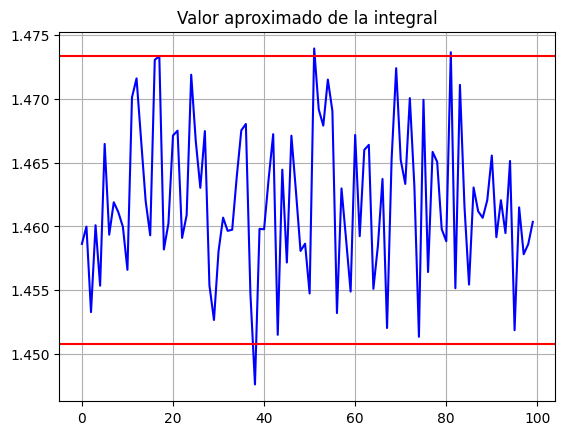

In [ ]:
plt.plot(l, color = "blue")
plt.title("Valor aproximado de la integral")
plt.axhline(mu-1.96*s, color ="red")
plt.axhline(mu+1.96*s, color = "red")
plt.grid()
plt.show()

Gráfica de la mejor aproximación de por donde fluctua el valor real de la integral y las líneas rojas, son los intervalos de confianza, que indican que el valor real se encuentra dentro de ellos (son cotas).

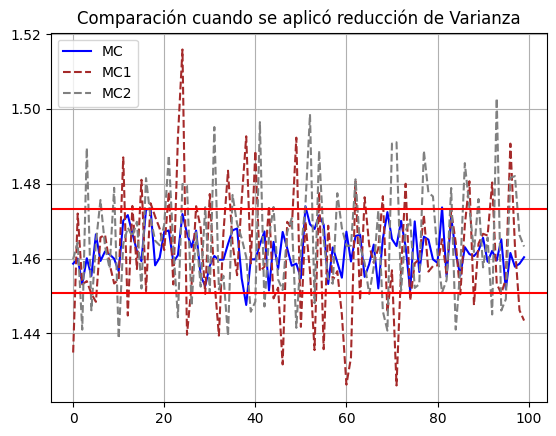

In [ ]:
plt.plot(l, color = "blue", label = "MC")
plt.plot(l1, color = "brown", linestyle = "--",  label = "MC1")
plt.plot(l2, color = "gray", linestyle = "--", label = "MC2")
plt.title("Comparación cuando se aplicó reducción de Varianza")
plt.axhline(mu-1.96*s, color ="red")
plt.axhline(mu+1.96*s, color = "red")
plt.legend()
plt.grid()
plt.show()

Así se ven las 3 aproximaciones en un mismo plano, lo cual se aprecia que es mejor estimador cuando se aplica el método de reducción de varianza, con el mismo número de experimentos en cada caso.

#**BOOTSTRAP**

Esta es una muestra aleatoria de 12 tiempos de entrega:

$$35,42,38,40,45,37,39,41,44,36,43,40$$

In [ ]:
def boot():
  l = []
  datos = [35,36,37,38,39,40,40,41,42,43,44,45]
  n = len(datos)
  for i in range(n):
    x = r.choice(datos)
    l.append(x)
  mu = np.mean(l)
  sd = np.std(l)
  return l

Se crea una función bootstrap que dado un conjunto de datos devuelve una muestra a partir del mismo conjunto de datos, estos se seleccionan deacuerdo a una probabilidad implícita, lo anterior se guarda en una lista, misma que se retorna la función

In [ ]:
def muestras(n):
  l = []
  for i in range(n):
    m = boot()
    l.append(np.mean(m))
  mu = np.mean(l)
  sd = np.std(l)
  return l, mu, sd

Ya que se creo una función que genera muestras bootstrap ahora se crea otra función que llama $n-$veces a la función B, se obtiene la media de la función que retorne boot y se guarda en una lista que incluye las medias de cada muestra, para posteriormente obtener las media de medias y la desviación estándar de medias.

In [ ]:
n = 1000
l, mu, sd = muestras(n)

Se realizan $1000$ experimentos y se retornan $\mu$ y $\sigma$ así como una lista de medias

In [ ]:
mu

np.float64(39.95658333333333)

Aquí se tiene $\mu$ de cada media obtenedia de cada muestra generada

In [ ]:
sd

np.float64(0.8739500009535252)

Este es $\sigma$ de la lista de medias de cada muestra (1000)

In [ ]:
IC = [np.percentile(l, 2.5),np.percentile(l, 97.5)]
IC

[np.float64(38.25), np.float64(41.666666666666664)]

Y finalmente se dan los percentiles $2.5$ y $97.5$ para obtener el intervalo de confianza B del $95\%$ mismo que engloba a la media verdadera del conjunto original de datos

#**JACKKNIFE**

Esta es una muestra aleatoria de 12 tiempos de entrega:

$$35,42,38,40,45,37,39,41,44,36,43,40$$

In [ ]:
def jack():
  muestra = [35,42,38,40,45,37,39,41,44,36,43,40]
  n = len(muestra)
  l = []
  for i in range(n):
    nuevo = muestra.copy()
    nuevo.pop(i)
    l.append(np.mean(nuevo))
  theta = np.mean(l)
  s = 0
  for j in l:
    s += (theta - j)**2
  var = (n-1)/n * s
  return l, theta, var

Se define la función de JACKKNIFE que consiste en dada una muestra se eliminan 1 por 1 cada elemento, de manera que se van a obtener 12 muestras de 11 elementos cada una, aquí es sin remuestreo, sino que se toman los mismos datos que ya se tienen a excepción del que se quitó.

Se obtienen las medias de cada muestra y se guardan en una lista, para posteriormente obtener la media de esa lista de medias. Además se calcula la varianza con la formula $$var = \frac{n-1}{n} \sum_{i=1}^n (\theta - \hat{\theta_i})^2$$

Donde $$\theta = \frac{1}{n} \sum_{i=1}^n \hat{\theta_i}$$

$\hat{\theta_i} $ es la media de cada muestra y $\theta $ es la media de las medias de muestras

In [ ]:
l,t,v = jack()

Se llama a la función creada anteriormente, misma que me retorna las $n-1$ muestras, la media de medias y la varianza

In [ ]:
t

np.float64(40.0)

Aquí se aprecia la media de medias ($\theta$)

In [ ]:
v

np.float64(0.8333333333333354)

La varianza calculada con la fomrula dada

In [ ]:
sd = np.sqrt(v)
sd

np.float64(0.912870929175278)

Y la desviación estándar, que es la raíz de la varianza

In [ ]:
IC = [np.percentile(l, 2.5),np.percentile(l, 97.5)]
IC

[np.float64(39.570454545454545), np.float64(40.429545454545455)]

Finalmente se muestra el intervalo de confianza al $95\%$ usando los percentiles $2.5$ y $97.5$ este intervalo contiene a la media verdadera del conjunto original de datos.